In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
from Log_Extractor import LogExtractor
import os
import csv

In [3]:
df = pd.read_csv('./extracted_csv/nobit.csv')
print(df.head())

                         Time  Actual_P1_g_s1_HD1  Actual_P1_g_s2_HD1  \
0  2026-04-03 13:53:23.073906                 0.0                 0.0   
1  2026-04-03 13:53:24.999432                 0.0                 0.0   
2  2026-04-03 13:53:26.762015                 0.0                 0.0   
3  2026-04-03 13:53:28.752030                 0.0                 0.0   
4  2026-04-03 13:53:32.027876                 0.0                 0.0   

   Actual_P1_g_s3_HD1  Actual_P1_g_s4_HD1  Actual_P1_g_s5_HD1  \
0                 0.0                 0.0                 0.0   
1                 0.0                 0.0                 0.0   
2                 0.0                 0.0                 0.0   
3                 0.0                 0.0                 0.0   
4                 0.0                 0.0                 0.0   

   Actual_P1_g_s6_HD1  Actual_P1_g_s1_HD2  Actual_P1_g_s2_HD2  \
0                 0.0              3210.0              4630.0   
1                 0.0              3210.

In [4]:
df = df.drop(columns=['Time'])
# 1. 고유값(unique) 개수를 확인하여 동적/정적 컬럼 분리
# 값이 딱 1개뿐이거나(완전 고정) 모두 결측치인 경우 정적(Static)으로 간주
static_cols = [col for col in df.columns if df[col].nunique(dropna=True) <= 1]

# 값이 2개 이상 존재하는 경우 동적(Dynamic)으로 간주
dynamic_cols = [col for col in df.columns if col not in static_cols]

# 2. 결과 확인
print(f"📌 전체 변수: {len(df.columns)}개")
print(f"🛑 정적 변수 (값이 안 변함): {len(static_cols)}개")
print(f"📈 동적 변수 (값이 변함): {len(dynamic_cols)}개\n")

print("--- 🛑 정적 변수 리스트 ---")
print(static_cols)
print("\n--- 📈 동적 변수 리스트 ---")
print(dynamic_cols)

📌 전체 변수: 137개
🛑 정적 변수 (값이 안 변함): 104개
📈 동적 변수 (값이 변함): 33개

--- 🛑 정적 변수 리스트 ---
['Actual_P1_g_s4_HD1', 'Actual_P1_g_s5_HD1', 'Actual_P1_g_s6_HD1', 'Actual_P1_g_s4_HD2', 'Actual_P1_g_s5_HD2', 'Actual_P1_g_s6_HD2', 'Actual_P1_g_s4_HD3', 'Actual_P1_g_s5_HD3', 'Actual_P1_g_s6_HD3', 'Actual_P1_g_s6_HD4', 'MTK_FEED_ERR_T_P1', 'Para_DM_Press_H_Set_P1', 'Para_DM_Press_L_Set_P1', 'Pump_Cir_SPD_Set_P1', 'Para_DM_H_ExSet_P1', 'TK_Temp_H_Set_P1', 'TK_Temp_SV_P1', 'TK_Temp_L_Set_P1', 'TK_Level_Max_Set_P1', 'TK_Level_Stop_Set_P1', 'TK_Level_Start_Set_P1', 'TK_Level_Min_Set_P1', 'TK_FEED_ERR_T_P1', 'STK_Temp_PV_P1', 'STK_Temp_H_Set_P1', 'STK_Temp_SV_P1', 'STK_Temp_L_Set_P1', 'STK_Level_PV_P1', 'STK_Level_Max_Set_P1', 'STK_Level_Stop_Set_P1', 'STK_Level_Start_Set_P1', 'STK_Level_Min_Set_P1', 'STK_FEED_ERR_T_P1', 'Ana_Max___PT_P1', 'Gain___PT_P1', 'OffSet___PT_P1', 'Scale_Max___PT_P1', 'Ana_Max___TT_P1', 'Gain___TT_P1', 'OffSet___TT_P1', 'Scale_Max___TT_P1', 'Ana_In___TT_STK_P1', 'Ana_Max___TT_STK_P1',

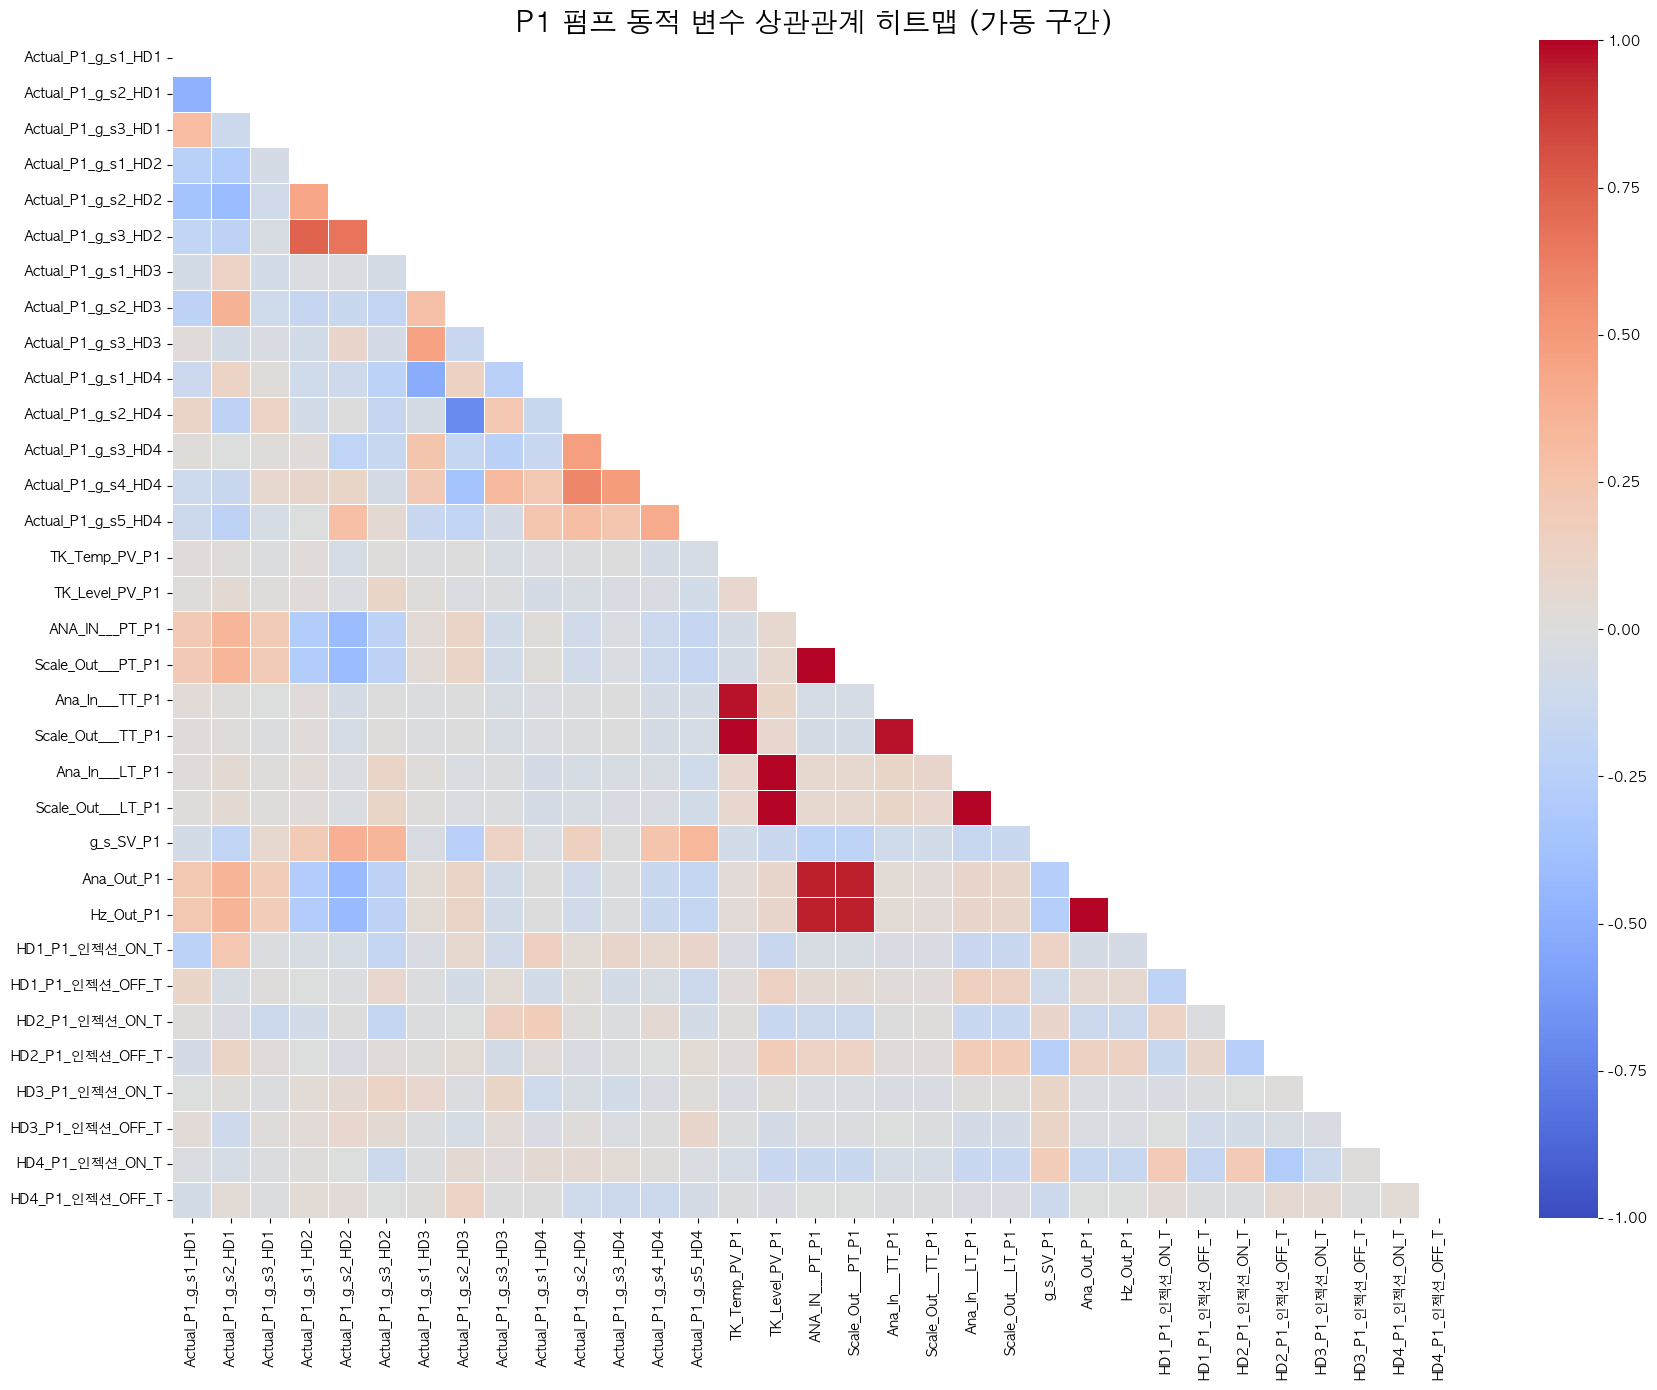

--- 🔥 강한 상관관계를 가진 변수 쌍 (절대값 0.7 이상) 🔥 ---
              변수 1               변수 2      상관계수
         Hz_Out_P1         Ana_Out_P1  1.000000
 Scale_Out___PT_P1     ANA_IN___PT_P1  0.999908
    TK_Level_PV_P1  Scale_Out___LT_P1  0.999509
     TK_Temp_PV_P1  Scale_Out___TT_P1  0.996202
 Scale_Out___LT_P1     Ana_In___LT_P1  0.996083
    TK_Level_PV_P1     Ana_In___LT_P1  0.995989
    Ana_In___TT_P1  Scale_Out___TT_P1  0.972156
    Ana_In___TT_P1      TK_Temp_PV_P1  0.971972
    ANA_IN___PT_P1          Hz_Out_P1  0.949743
    ANA_IN___PT_P1         Ana_Out_P1  0.949743
         Hz_Out_P1  Scale_Out___PT_P1  0.949627
 Scale_Out___PT_P1         Ana_Out_P1  0.949627
Actual_P1_g_s3_HD2 Actual_P1_g_s1_HD2  0.741945
Actual_P1_g_s2_HD3 Actual_P1_g_s2_HD4 -0.702147


In [5]:
import numpy as np
# 한글 폰트 설정 (환경에 맞게 수정)
plt.rc('font', family='AppleGothic') # 맥은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False 

# 1. 펌프가 가동 중일 때만 필터링 (가동 정지 시의 0 값들이 상관관계를 왜곡하는 것 방지)
if 'Pump_Run_P1' in df.columns:
    df_active = df[df['Pump_Run_P1'] > 0][dynamic_cols]
else:
    df_active = df[dynamic_cols]

# 2. 상관계수 계산 (피어슨)
corr_matrix = df_active.corr()

# 3. 히트맵 시각화
# 변수가 많을 수 있으므로 figure 사이즈를 넉넉하게 잡습니다.
plt.figure(figsize=(18, 14))

# 대각선 기준 위쪽 중복 데이터 가리기 (가독성 향상)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# annot=False 로 설정하여 글씨가 뭉개지는 것을 방지
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=False,     
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            linewidths=0.5)

plt.title("P1 펌프 동적 변수 상관관계 히트맵 (가동 구간)", fontsize=20)
plt.tight_layout()
plt.show()

# 4. 상관관계가 높은 강한 변수 쌍만 자동으로 추출하기
print("--- 🔥 강한 상관관계를 가진 변수 쌍 (절대값 0.7 이상) 🔥 ---")

# 상관계수를 1차원 시리즈로 풀고 정렬
corr_pairs = corr_matrix.unstack().sort_values(kind="quicksort", ascending=False)

# 자기 자신과의 상관관계(1.0)는 제외
corr_pairs = corr_pairs[corr_pairs != 1.0]

# 절대값이 0.7 이상인 데이터만 남기고, 중복되는 쌍(A-B, B-A) 제거
high_corr = corr_pairs[abs(corr_pairs) >= 0.7].drop_duplicates()

# 결과 출력
df_high_corr = high_corr.reset_index()
df_high_corr.columns = ['변수 1', '변수 2', '상관계수']
print(df_high_corr.to_string(index=False))

In [15]:
ext = LogExtractor()
good_df = ext.get_data(start_time="2026-04-03T04:00:00Z", end_time="2026-04-03T15:00:00Z", target_tags=["Actual_P1_SEL1_HD1", "Actual_P1_SEL2_HD1", "Actual_P1_SEL3_HD1", "Actual_P1_SEL4_HD1", "Actual_P1_SEL5_HD1", "Actual_P1_SEL6_HD1", "Actual_P1_g_s1_HD1", "Actual_P1_g_s2_HD1", "Actual_P1_g_s3_HD1", "Actual_P1_g_s4_HD1", "Actual_P1_g_s5_HD1", "Actual_P1_g_s6_HD1", "Para_DM_Press_H_Set_P1", "Para_DM_Press_L_Set_P1", "Pump_Cir_SPD_Set_P1", "Para_DM_H_ExSet_P1", "ANA_IN___PT_P1", "Ana_Max___PT_P1", "Gain___PT_P1", "OffSet___PT_P1", "Scale_Max___PT_P1", "Scale_Out___PT_P1", "Imp_L_FT_P1_Real", "Specific_gravity_FT_P1_Real", "OffSet_FT_P1", "Scale_Out___FT_P1", "Err__PT_P1", "Err__PT_HD_P1", "g_s_SV_P1", "Pump_rpm_P1", "Pump_Capa_P1", "Ana_Out_Max_P1", "Gain_P1", "Pump_Hz_Max_P1", "Max_Capa_P1", "Ana_Out_P1", "Hz_Out_P1", "Err_P1", "Pump_On_Sw_P1", "Pump_Trip_P1", "Pump_BuildUp_P1", "Pump_Run_P1", "A_CAL_Base_Qty_HMI_P1", "A_CAL_Range_Qty_HMI_P1", "A_CAL_Result_H_QTY_HMI_P1", "A_CAL_Result_L_QTY_HMI_P1", "Cal_Nozzle_P1", "Press_High_Err_P1", "Press_Low_Err_P1", "Pump_In_Press_Low_Err_P1", "PRE_CNT_P1", "NOW_CNT_P1", "CNT_QTY_P1", "HSC_FRQ_P1", "Data기록 CNT_P1", "TK_Temp_PV_P1", "TK_Level_PV_P1"])
print(good_df.tail())

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🔍 데이터 추출 시작... (2026-04-03T04:00:00Z ~ 2026-04-03T15:00:00Z)
✅ 추출 완료! 총 17946행, 57개 컬럼 확보.
                            Actual_P1_SEL1_HD1  Actual_P1_SEL2_HD1  \
Time                                                                 
2026-04-03 23:59:50.527182                 0.0                 0.0   
2026-04-03 23:59:53.177960                 0.0                 0.0   
2026-04-03 23:59:57.044637                 0.0                 0.0   
2026-04-03 23:59:57.264929                 0.0                 0.0   
2026-04-03 23:59:59.278096                 0.0                 0.0   

                            Actual_P1_SEL3_HD1  Actual_P1_SEL4_HD1  \
Time                                                                 
2026-04-03 23:59:50.527182                 0.0                 0.0   
2026-04-03 23:59:53.177960                 0.0                 0.0   
2026-04-03 23:59:57.044637                 0.0                 0.0   
2026-04-03 23:59:57.264929    

In [16]:
ext.save_to_csv(good_df)

💾 [저장 완료] 분석용 CSV 파일이 생성되었습니다: ./extracted_csv/2026-04-04_180306_analysis.csv


In [18]:
# 1. 고유값(unique) 개수를 확인하여 동적/정적 컬럼 분리
# 값이 딱 1개뿐이거나(완전 고정) 모두 결측치인 경우 정적(Static)으로 간주
static_cols = [col for col in good_df.columns if good_df[col].nunique(dropna=True) <= 1]

# 값이 2개 이상 존재하는 경우 동적(Dynamic)으로 간주
dynamic_cols = [col for col in good_df.columns if col not in static_cols]

# 2. 결과 확인
print(f"📌 전체 변수: {len(good_df.columns)}개")
print(f"🛑 정적 변수 (값이 안 변함): {len(static_cols)}개")
print(f"📈 동적 변수 (값이 변함): {len(dynamic_cols)}개\n")

print("--- 🛑 정적 변수 리스트 ---")
print(static_cols)
print("\n--- 📈 동적 변수 리스트 ---")
print(dynamic_cols)

📌 전체 변수: 57개
🛑 정적 변수 (값이 안 변함): 39개
📈 동적 변수 (값이 변함): 18개

--- 🛑 정적 변수 리스트 ---
['Actual_P1_SEL5_HD1', 'Actual_P1_SEL6_HD1', 'Actual_P1_g_s4_HD1', 'Actual_P1_g_s5_HD1', 'Actual_P1_g_s6_HD1', 'Para_DM_Press_H_Set_P1', 'Para_DM_Press_L_Set_P1', 'Pump_Cir_SPD_Set_P1', 'Para_DM_H_ExSet_P1', 'Ana_Max___PT_P1', 'Gain___PT_P1', 'OffSet___PT_P1', 'Scale_Max___PT_P1', 'Imp_L_FT_P1_Real', 'Specific_gravity_FT_P1_Real', 'OffSet_FT_P1', 'Err__PT_P1', 'Err__PT_HD_P1', 'Pump_rpm_P1', 'Pump_Capa_P1', 'Ana_Out_Max_P1', 'Gain_P1', 'Pump_Hz_Max_P1', 'Max_Capa_P1', 'Err_P1', 'Pump_On_Sw_P1', 'Pump_Trip_P1', 'Pump_BuildUp_P1', 'Pump_Run_P1', 'A_CAL_Base_Qty_HMI_P1', 'A_CAL_Range_Qty_HMI_P1', 'A_CAL_Result_H_QTY_HMI_P1', 'A_CAL_Result_L_QTY_HMI_P1', 'Cal_Nozzle_P1', 'Press_High_Err_P1', 'Press_Low_Err_P1', 'Pump_In_Press_Low_Err_P1', 'HSC_FRQ_P1', 'Data기록 CNT_P1']

--- 📈 동적 변수 리스트 ---
['Actual_P1_SEL1_HD1', 'Actual_P1_SEL2_HD1', 'Actual_P1_SEL3_HD1', 'Actual_P1_SEL4_HD1', 'Actual_P1_g_s1_HD1', 'Actual_P1_g_s

In [ ]:
int_df = ext.get_data(start_time="2026-04-03T04:00:00Z", end_time="2026-04-03T15:00:00Z", target_tags=["Actual_P1_g_s1_HD1", "Actual_P1_g_s2_HD1", "Actual_P1_g_s3_HD1", "Actual_P1_g_s4_HD1", "Actual_P1_g_s5_HD1", "Actual_P1_g_s6_HD1", "Para_DM_Press_H_Set_P1", "Para_DM_Press_L_Set_P1", "Pump_Cir_SPD_Set_P1", "Para_DM_H_ExSet_P1", "ANA_IN___PT_P1", "Ana_Max___PT_P1", "Gain___PT_P1", "OffSet___PT_P1", "Scale_Max___PT_P1", "Scale_Out___PT_P1", "Imp_L_FT_P1_Real", "Specific_gravity_FT_P1_Real", "OffSet_FT_P1", "Scale_Out___FT_P1", "g_s_SV_P1", "Pump_rpm_P1", "Pump_Capa_P1", "Ana_Out_Max_P1", "Gain_P1", "Pump_Hz_Max_P1", "Max_Capa_P1", "Ana_Out_P1", "Hz_Out_P1", "A_CAL_Base_Qty_HMI_P1", "A_CAL_Range_Qty_HMI_P1", "A_CAL_Result_H_QTY_HMI_P1", "A_CAL_Result_L_QTY_HMI_P1", "PRE_CNT_P1", "NOW_CNT_P1", "CNT_QTY_P1", "HSC_FRQ_P1", "Data기록 CNT_P1", "TK_Temp_PV_P1", "TK_Level_PV_P1"])

In [ ]:
bit_df = ext.get_data(start_time="2026-04-03T04:00:00Z", end_time="2026-04-03T15:00:00Z", target_tags=["Actual_P1_SEL1_HD1", "Actual_P1_SEL2_HD1", "Actual_P1_SEL3_HD1", "Actual_P1_SEL4_HD1", "Actual_P1_SEL5_HD1", "Actual_P1_SEL6_HD1", "Err__PT_P1", "Err__PT_HD_P1", "Err_P1", "Pump_On_Sw_P1", "Pump_Trip_P1", "Pump_BuildUp_P1", "Pump_Run_P1", "Cal_Nozzle_P1", "Press_High_Err_P1", "Press_Low_Err_P1", "Pump_In_Press_Low_Err_P1"])

🔍 데이터 추출 시작... (2026-04-03T04:00:00Z ~ 2026-04-03T15:00:00Z)
✅ 추출 완료! 총 17946행, 17개 컬럼 확보.
                            Actual_P1_SEL1_HD1  Actual_P1_SEL2_HD1  \
Time                                                                 
2026-04-03 13:53:23.073906                 0.0                 0.0   
2026-04-03 13:53:24.999432                 0.0                 0.0   
2026-04-03 13:53:26.762015                 0.0                 0.0   
2026-04-03 13:53:28.752030                 0.0                 0.0   
2026-04-03 13:53:32.027876                 0.0                 0.0   

                            Actual_P1_SEL3_HD1  Actual_P1_SEL4_HD1  \
Time                                                                 
2026-04-03 13:53:23.073906                 0.0                 0.0   
2026-04-03 13:53:24.999432                 0.0                 0.0   
2026-04-03 13:53:26.762015                 0.0                 0.0   
2026-04-03 13:53:28.752030                 0.0                 0.0  

In [21]:
int_static_cols = [col for col in int_df.columns if int_df[col].nunique(dropna=True) <= 1]

# 값이 2개 이상 존재하는 경우 동적(Dynamic)으로 간주
int_dynamic_cols = [col for col in int_df.columns if col not in int_static_cols]

# 2. 결과 확인
print(f"📌 전체 변수: {len(int_df.columns)}개")
print(f"🛑 정적 변수 (값이 안 변함): {len(int_static_cols)}개")
print(f"📈 동적 변수 (값이 변함): {len(int_dynamic_cols)}개\n")

print("--- 🛑 정적 변수 리스트 ---")
print(int_static_cols)
print("\n--- 📈 동적 변수 리스트 ---")
print(int_dynamic_cols)

📌 전체 변수: 40개
🛑 정적 변수 (값이 안 변함): 26개
📈 동적 변수 (값이 변함): 14개

--- 🛑 정적 변수 리스트 ---
['Actual_P1_g_s4_HD1', 'Actual_P1_g_s5_HD1', 'Actual_P1_g_s6_HD1', 'Para_DM_Press_H_Set_P1', 'Para_DM_Press_L_Set_P1', 'Pump_Cir_SPD_Set_P1', 'Para_DM_H_ExSet_P1', 'Ana_Max___PT_P1', 'Gain___PT_P1', 'OffSet___PT_P1', 'Scale_Max___PT_P1', 'Imp_L_FT_P1_Real', 'Specific_gravity_FT_P1_Real', 'OffSet_FT_P1', 'Pump_rpm_P1', 'Pump_Capa_P1', 'Ana_Out_Max_P1', 'Gain_P1', 'Pump_Hz_Max_P1', 'Max_Capa_P1', 'A_CAL_Base_Qty_HMI_P1', 'A_CAL_Range_Qty_HMI_P1', 'A_CAL_Result_H_QTY_HMI_P1', 'A_CAL_Result_L_QTY_HMI_P1', 'HSC_FRQ_P1', 'Data기록 CNT_P1']

--- 📈 동적 변수 리스트 ---
['Actual_P1_g_s1_HD1', 'Actual_P1_g_s2_HD1', 'Actual_P1_g_s3_HD1', 'ANA_IN___PT_P1', 'Scale_Out___PT_P1', 'Scale_Out___FT_P1', 'g_s_SV_P1', 'Ana_Out_P1', 'Hz_Out_P1', 'PRE_CNT_P1', 'NOW_CNT_P1', 'CNT_QTY_P1', 'TK_Temp_PV_P1', 'TK_Level_PV_P1']


In [27]:
int_df['Actual_P1_g_s1_HD1'].describe()

count    17946.000000
mean       745.765073
std       1121.417528
min          0.000000
25%          0.000000
50%          0.000000
75%       2340.000000
max       2850.000000
Name: Actual_P1_g_s1_HD1, dtype: float64

In [45]:
# 1. 한글 폰트 설정 (환경에 맞게 수정: Windows는 'Malgun Gothic', Mac은 'AppleGothic')
plt.rc('font', family='AppleGothic') 
plt.rcParams['axes.unicode_minus'] = False 

# ==========================================
# 2. 분석용 변수 그룹화 (올려주신 리스트 기반)
# ==========================================

# 가설의 핵심: Head별 설정값 (s1 ~ s4)
s_setting_vars = [
    'Actual_P1_g_s1_HD1', 'Actual_P1_g_s2_HD1', 
    'Actual_P1_g_s3_HD1'
]

# P1 펌프의 실제 동적 출력 변수 (PV/Out)
p1_dynamic_outputs = [
    'ANA_IN___PT_P1', 'Scale_Out___PT_P1', 'Scale_Out___FT_P1', 'g_s_SV_P1', 'Ana_Out_P1', 'Hz_Out_P1', 'PRE_CNT_P1', 'NOW_CNT_P1', 'CNT_QTY_P1', 'TK_Temp_PV_P1', 'TK_Level_PV_P1'         # 탱크 온도 (원액 점도 영향)
]

# 필터링용 인터락/상태 BIT 변수 (int_df에 포함되어 있다면 수치형으로 가져옴)
interlock_vars = [
    'Pump_Run_P1',           # 펌프 가동 중 (핵심 필터)
    'Press_High_Err_P1',     # 고압 에러
    'Err_P1'                 # 펌프 종합 에러
]

# 분석에 사용할 수치형 변수 통합
analysis_cols = s_setting_vars + p1_dynamic_outputs

# 여기서는 int_df에 필요한 동적 변수들이 다 있다고 가정하고 진행합니다.
eda_df = pd.concat([int_df[analysis_cols], bit_df[interlock_vars]], axis=1)

In [46]:
# BIT 데이터 Boolean 데이터 Boolean 데이터 Boolean 데이터
bool_cols = [col for col in eda_df.columns if col in bit_df.columns or col in interlock_vars]
for col in bool_cols:
    eda_df[col] = eda_df[col].astype(int)

# [가장 중요] 펌프가 실제로 구동 중인 구간만 필터링
# 펌프가 멈췄을 때의 0값들이 상관관계를 왜곡하는 것을 방지
# D00809.4 'Pump_Run_P1' 변수가 1인 구간만 사용
if 'Pump_Run_P1' in eda_df.columns:
    eda_df = eda_df[eda_df['Pump_Run_P1'] == 0]
    print(f"✅ 펌프 가동 구간 데이터 {len(eda_df)}행 추출 완료!")
else:
    print("⚠️ 'Pump_Run_P1' 변수가 없어 전체 데이터로 진행합니다. 결과가 왜곡될 수 있습니다.")

✅ 펌프 가동 구간 데이터 17946행 추출 완료!



📊 [상관관계 분석] 설정값 vs 실제 출력 변수


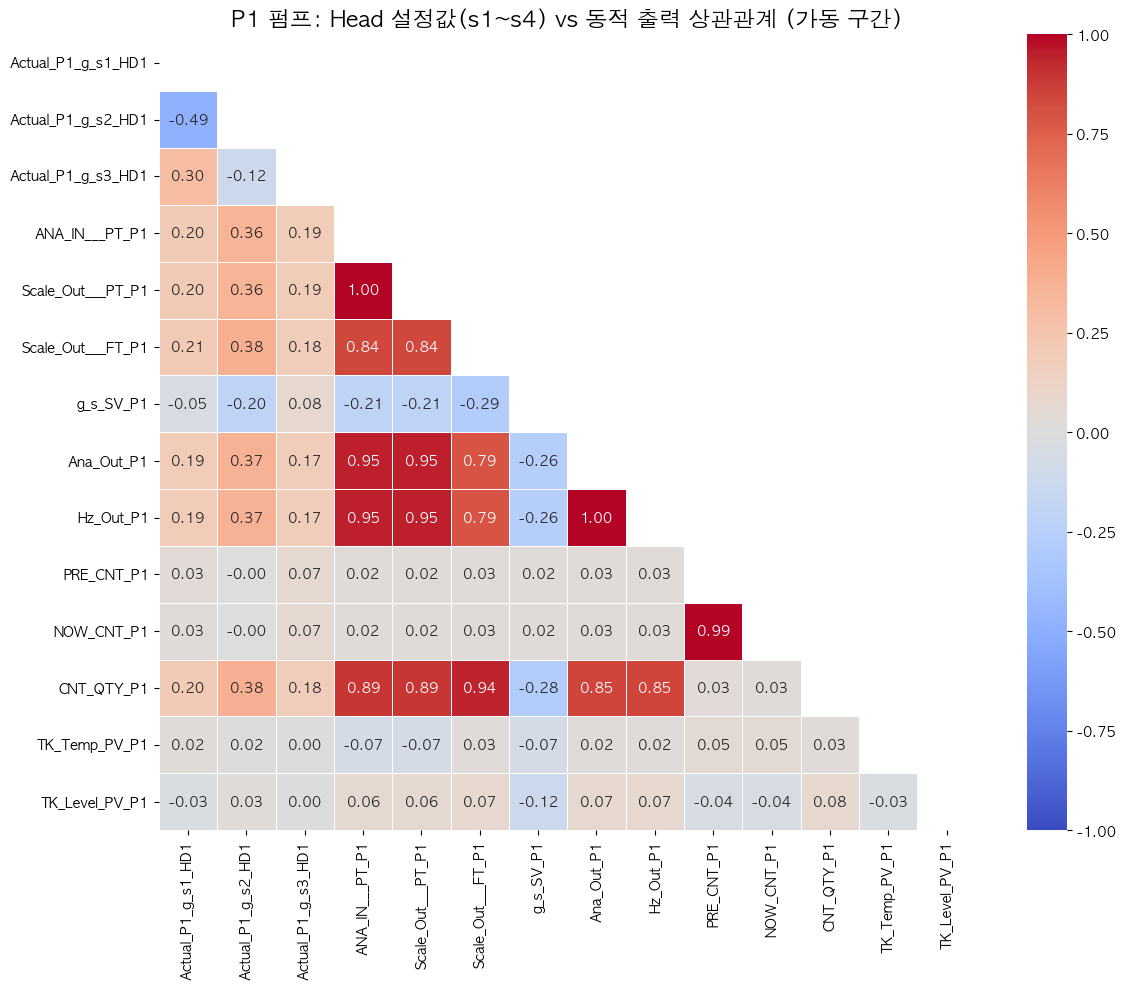

In [47]:


print("\n📊 [상관관계 분석] 설정값 vs 실제 출력 변수")
plt.figure(figsize=(12, 10))

# 피어슨 상관계수 계산
corr_matrix = eda_df[s_setting_vars + p1_dynamic_outputs].corr()

# 삼각형 마스크 설정 (중복 및 자기 자신 제거)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True,      # 숫자 표기
            fmt=".2f",       # 소수점 둘째 자리
            cmap='coolwarm', # 양의 상관(빨강), 음의 상관(파랑)
            vmin=-1, vmax=1, # 범위 고정
            linewidths=0.5)

plt.title("P1 펌프: Head 설정값(s1~s4) vs 동적 출력 상관관계 (가동 구간)", fontsize=16)
plt.tight_layout()
plt.show()

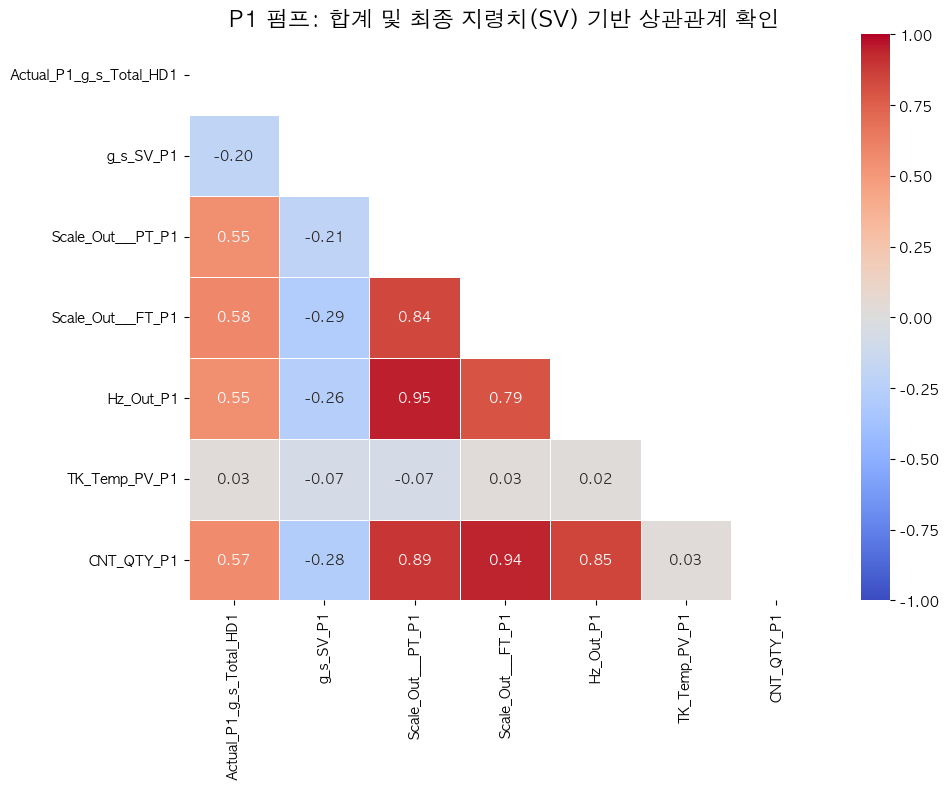

In [49]:
eda_df['Actual_P1_g_s_Total_HD1'] = (
    eda_df['Actual_P1_g_s1_HD1'].fillna(0) + 
    eda_df['Actual_P1_g_s2_HD1'].fillna(0) + 
    eda_df['Actual_P1_g_s3_HD1'].fillna(0)
)

# 2. 진검승부를 위한 핵심 변수 리스트 재구성
# 빈칸으로 나오던 변수들은 빼고, 새로 만든 합계와 진짜 지령치(g_s_SV_P1)를 추가합니다.
new_analysis_cols = [
    'Actual_P1_g_s_Total_HD1',  # 우리가 방금 만든 4개 합계
    'g_s_SV_P1',                # [핵심] PLC가 최종 선택한 현재 목표 토출량
    'Scale_Out___PT_P1',        # 토출 압력
    'Scale_Out___FT_P1',        # 실제 측정 유량
    'Hz_Out_P1',                # 인버터 출력 주파수
    'TK_Temp_PV_P1',             # 원액 온도
    'CNT_QTY_P1'
]

# df에 변수가 존재하는지 안전하게 확인
new_analysis_cols = [col for col in new_analysis_cols if col in eda_df.columns]

# 3. 새로운 상관관계 히트맵 그리기
plt.figure(figsize=(10, 8))
corr_matrix_new = eda_df[new_analysis_cols].corr()

# 대각선 위쪽 가리기
mask_new = np.triu(np.ones_like(corr_matrix_new, dtype=bool))

sns.heatmap(corr_matrix_new, 
            mask=mask_new,
            annot=True,      
            fmt=".2f",       
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            linewidths=0.5)

plt.title("P1 펌프: 합계 및 최종 지령치(SV) 기반 상관관계 확인", fontsize=16)
plt.tight_layout()
plt.show()

In [53]:
df['Pump_Run_P2'].describe()

KeyError: 'Pump_Run_P2'